#  Handwritten Character Recognition

In [23]:
import subprocess
subprocess.run(['pip', 'install', 'numpy', 'matplotlib', 'scikit-learn', 'seaborn', 'tensorflow-cpu'], check=True)
print(' All packages installed!')

 All packages installed!


In [24]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print(' All libraries imported successfully!')
print('NumPy version    :', np.__version__)
import sklearn
print('Sklearn version  :', sklearn.__version__)

 All libraries imported successfully!
NumPy version    : 2.1.1
Sklearn version  : 1.7.2


In [25]:
print('Loading MNIST dataset...')

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

# Convert to NumPy & Normalize pixel values 0-1
X = np.array(mnist.data,   dtype=np.float32) / 255.0
y = np.array(mnist.target, dtype=np.int32)

print(' Dataset loaded!')
print(f'   X shape : {X.shape}  → (samples, pixels)')
print(f'   y shape : {y.shape}  → (labels)')
print(f'   Classes : {np.unique(y)}  (digits 0-9)')
print(f'   Min pixel value : {X.min()}')
print(f'   Max pixel value : {X.max()}')

Loading MNIST dataset...
 Dataset loaded!
   X shape : (70000, 784)  → (samples, pixels)
   y shape : (70000,)  → (labels)
   Classes : [0 1 2 3 4 5 6 7 8 9]  (digits 0-9)
   Min pixel value : 0.0
   Max pixel value : 1.0


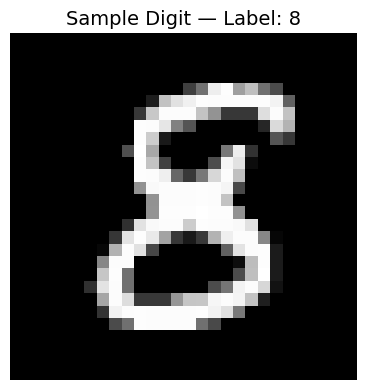

Label at index 3601: 8


In [26]:
# Show one sample digit
sample_index = 3601
some_digit       = X[sample_index]
some_digit_image = some_digit.reshape(28, 28)

plt.figure(figsize=(4, 4))
plt.imshow(some_digit_image, cmap='gray')
plt.title(f'Sample Digit — Label: {y[sample_index]}', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Label at index {sample_index}: {y[sample_index]}')

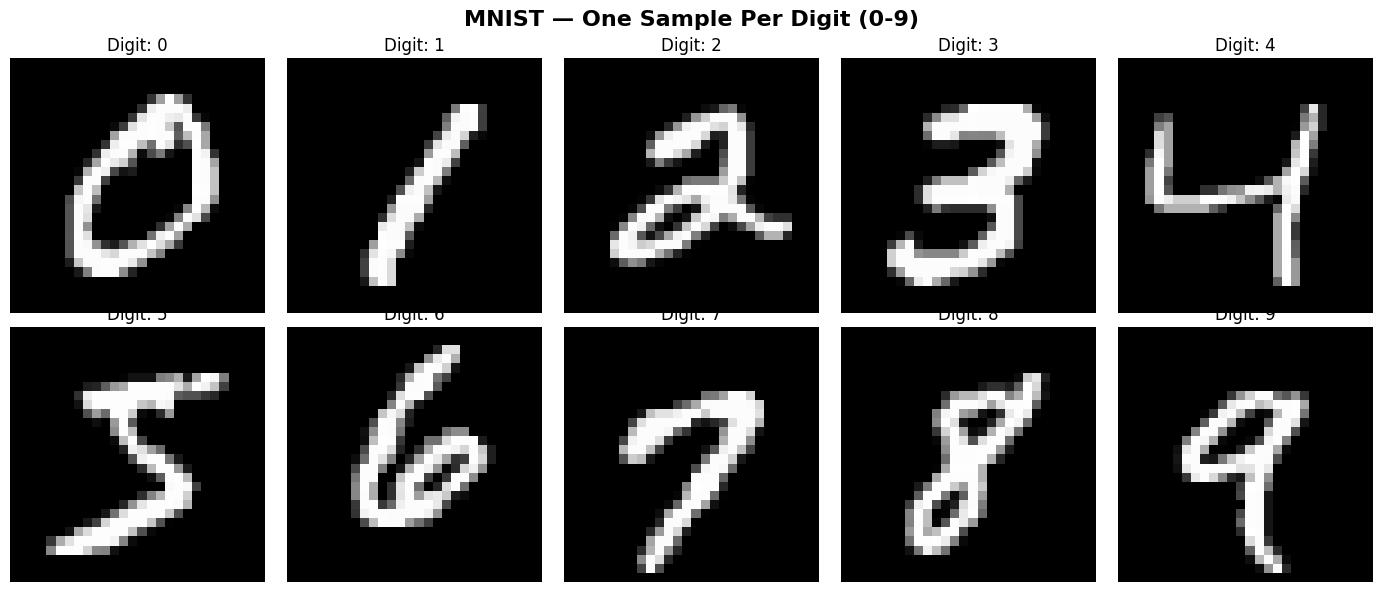

In [27]:
# Show one sample for each digit 0-9
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('MNIST — One Sample Per Digit (0-9)', fontsize=16, fontweight='bold')

for digit in range(10):
    idx = np.where(y == digit)[0][0]
    ax  = axes[digit // 5][digit % 5]
    ax.imshow(X[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

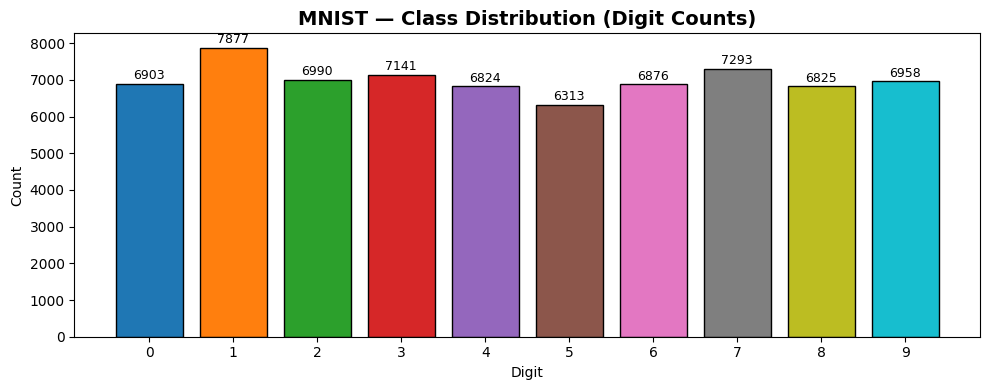

In [28]:
# Class distribution
plt.figure(figsize=(10, 4))
unique, counts = np.unique(y, return_counts=True)
bars = plt.bar(unique, counts, color=sns.color_palette('tab10', 10), edgecolor='black')
plt.title('MNIST — Class Distribution (Digit Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(range(10))
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [29]:
# Classic MNIST split: 60k train, 10k test
x_train, x_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# Shuffle training data
np.random.seed(42)
shuffle_index = np.random.permutation(len(x_train))
x_train = x_train[shuffle_index]
y_train = y_train[shuffle_index]

# Cast labels
y_train = y_train.astype(np.int8)
y_test  = y_test.astype(np.int8)

print(' Data split complete!')
print(f'   Training samples : {x_train.shape[0]}')
print(f'   Test samples     : {x_test.shape[0]}')

 Data split complete!
   Training samples : 60000
   Test samples     : 10000


In [30]:
# Binary labels: Is it a 2?
y_train_2 = (y_train == 2)
y_test_2  = (y_test  == 2)

print(f'Twos in training set : {y_train_2.sum()}')
print(f'Twos in test set     : {y_test_2.sum()}')

# Train binary logistic regression
print('\nTraining binary classifier...')
clf_binary = LogisticRegression(tol=0.1, max_iter=1000, random_state=42)
clf_binary.fit(x_train, y_train_2)
print(' Binary classifier trained!')

Twos in training set : 5958
Twos in test set     : 1032

Training binary classifier...
 Binary classifier trained!


Prediction  : [False]  ← Should be [True]
Probability : NOT-2 = 0.9977 | IS-2 = 0.0023


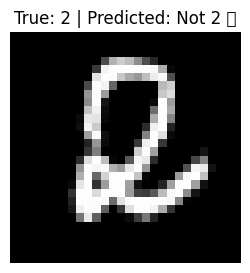

In [31]:
# Test binary classifier on an actual digit 2
idx_of_2  = np.where(y_train == 2)[0][0]
digit_2   = x_train[idx_of_2]

pred = clf_binary.predict([digit_2])
prob = clf_binary.predict_proba([digit_2])

print(f'Prediction  : {pred}  ← Should be [True]')
print(f'Probability : NOT-2 = {prob[0][0]:.4f} | IS-2 = {prob[0][1]:.4f}')

plt.figure(figsize=(3, 3))
plt.imshow(digit_2.reshape(28, 28), cmap='gray')
plt.title(f"True: 2 | Predicted: {'2 ' if pred[0] else 'Not 2 ❌'}")
plt.axis('off')
plt.show()

In [32]:
# Cross validation on binary classifier (small sample to save RAM)
gc.collect()

scores = cross_val_score(
    clf_binary,
    x_train[:10000].astype(np.float32),
    y_train_2[:10000],
    cv=3,
    scoring='accuracy'
)

print('Binary Classifier Cross-Validation:')
print(f'   Scores       : {scores}')
print(f'   Mean Accuracy: {scores.mean()*100:.2f}%')
print(f'   Std Deviation: {scores.std()*100:.2f}%')

Binary Classifier Cross-Validation:
   Scores       : [0.90041992 0.90069007 0.90069007]
   Mean Accuracy: 90.06%
   Std Deviation: 0.01%


In [33]:
print('Training Multiclass Logistic Regression...')
clf_multi = LogisticRegression(
    tol=0.1,
    max_iter=1000,
    random_state=42,
    solver='saga',
    n_jobs=-1
)
clf_multi.fit(x_train, y_train)
print(' Multiclass classifier trained!')

Training Multiclass Logistic Regression...
 Multiclass classifier trained!


In [34]:
# Evaluate multiclass
y_pred_multi = clf_multi.predict(x_test)
acc = accuracy_score(y_test, y_pred_multi)

print(f' Multiclass Logistic Regression Accuracy: {acc*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_multi, target_names=[str(i) for i in range(10)]))

 Multiclass Logistic Regression Accuracy: 92.49%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.97      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.93      0.93      0.93       982
           5       0.91      0.87      0.89       892
           6       0.93      0.95      0.94       958
           7       0.93      0.92      0.92      1028
           8       0.88      0.89      0.88       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



True label      : 8
Predicted label : 8
Result          :  Correct!


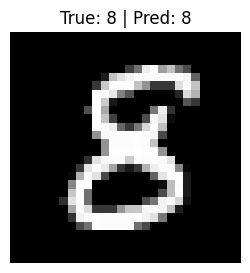

In [35]:
# Test multiclass on our sample digit
pred_sample = clf_multi.predict([some_digit])
print(f'True label      : {y[sample_index]}')
print(f'Predicted label : {pred_sample[0]}')
print(f'Result          : {" Correct!" if pred_sample[0] == y[sample_index] else "❌ Wrong"}')

plt.figure(figsize=(3, 3))
plt.imshow(some_digit.reshape(28, 28), cmap='gray')
plt.title(f'True: {y[sample_index]} | Pred: {pred_sample[0]}')
plt.axis('off')
plt.show()

In [36]:
print('Training MLP Neural Network...')
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=30,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(x_train, y_train)
print('\n MLP Neural Network trained!')

Training MLP Neural Network...
Iteration 1, loss = 0.33474066
Validation score: 0.951333
Iteration 2, loss = 0.11917182
Validation score: 0.967500
Iteration 3, loss = 0.07837938
Validation score: 0.973000
Iteration 4, loss = 0.05785807
Validation score: 0.973333
Iteration 5, loss = 0.04167766
Validation score: 0.974500
Iteration 6, loss = 0.03256833
Validation score: 0.974500
Iteration 7, loss = 0.02594646
Validation score: 0.974333
Iteration 8, loss = 0.01826090
Validation score: 0.979000
Iteration 9, loss = 0.01666785
Validation score: 0.975333
Iteration 10, loss = 0.01598920
Validation score: 0.974333
Iteration 11, loss = 0.01235394
Validation score: 0.976833
Iteration 12, loss = 0.01190915
Validation score: 0.977833
Iteration 13, loss = 0.00840825
Validation score: 0.972833
Iteration 14, loss = 0.01222454
Validation score: 0.975833
Iteration 15, loss = 0.01536077
Validation score: 0.970667
Iteration 16, loss = 0.00979602
Validation score: 0.978167
Iteration 17, loss = 0.00637304
Va

In [37]:
# Evaluate MLP
y_pred_mlp = mlp.predict(x_test)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print(f' MLP Neural Network Accuracy: {acc_mlp*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_mlp, target_names=[str(i) for i in range(10)]))

 MLP Neural Network Accuracy: 98.06%

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.96      0.99      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



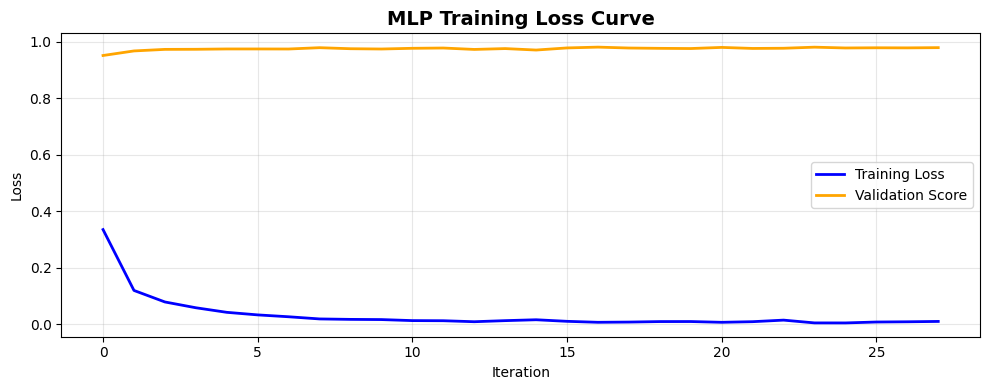

In [38]:
# Plot MLP training loss curve
plt.figure(figsize=(10, 4))
plt.plot(mlp.loss_curve_, label='Training Loss', color='blue', linewidth=2)
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    plt.plot(mlp.validation_scores_, label='Validation Score', color='orange', linewidth=2)
plt.title('MLP Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

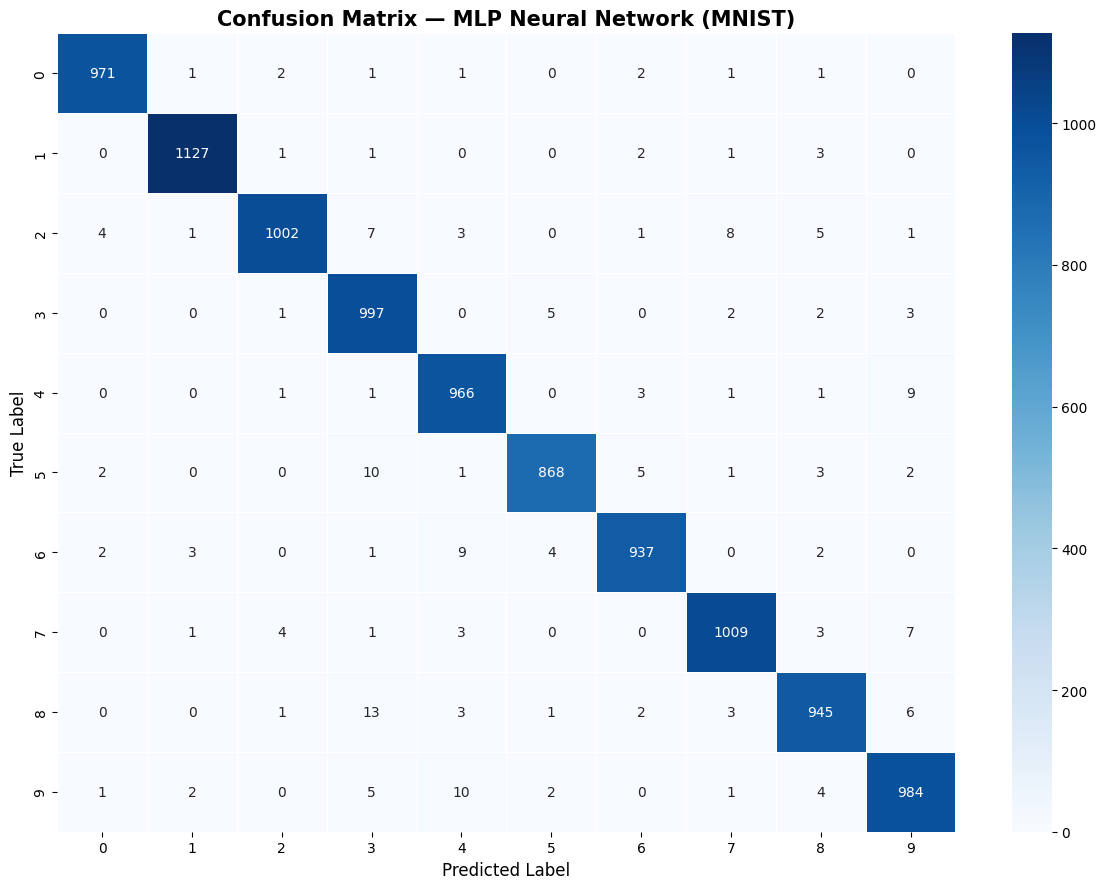

In [39]:
# Confusion matrix for MLP (best model)
cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    linewidths=0.5
)
plt.title('Confusion Matrix — MLP Neural Network (MNIST)', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

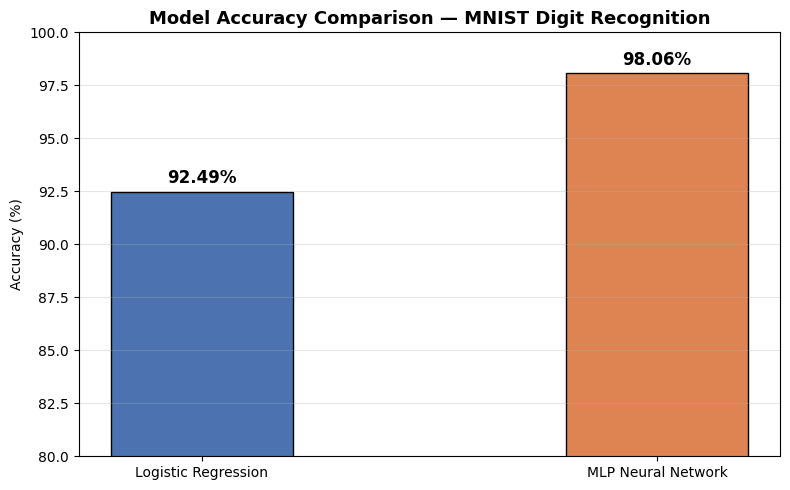


 Final Results:
   Logistic Regression      : 92.49%
   MLP Neural Network       : 98.06%


In [40]:
# Compare all models
models      = ['Logistic Regression', 'MLP Neural Network']
accuracies  = [
    accuracy_score(y_test, y_pred_multi) * 100,
    accuracy_score(y_test, y_pred_mlp)   * 100
]
colors = ['#4C72B0', '#DD8452']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', width=0.4)
plt.title('Model Accuracy Comparison — MNIST Digit Recognition',
          fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim([80, 100])
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n Final Results:')
for model, acc in zip(models, accuracies):
    print(f'   {model:25s}: {acc:.2f}%')

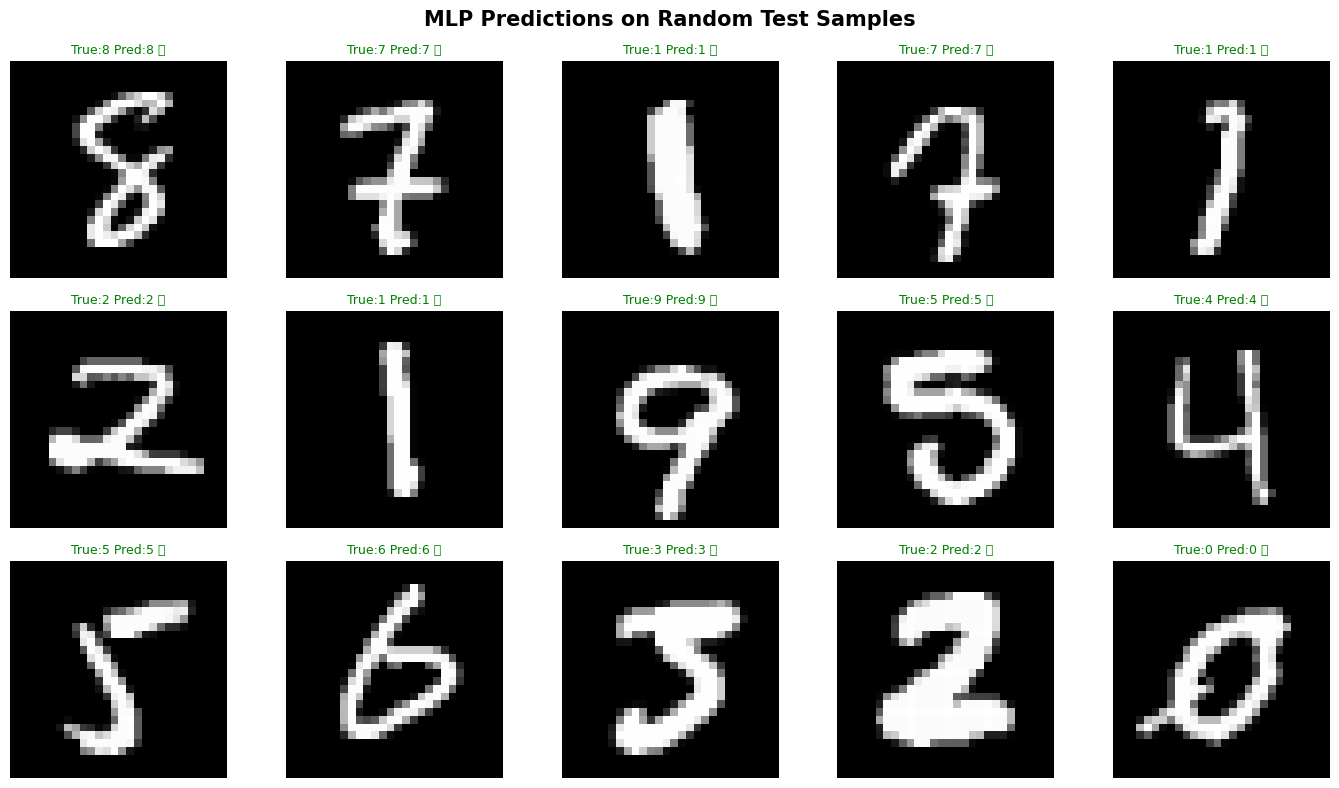

In [41]:
# Show 15 random predictions from test set
np.random.seed(0)
random_indices = np.random.choice(len(x_test), 15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('MLP Predictions on Random Test Samples', fontsize=15, fontweight='bold')

for i, idx in enumerate(random_indices):
    ax   = axes[i // 5][i % 5]
    pred = mlp.predict([x_test[idx]])[0]
    true = y_test[idx]
    correct = pred == true

    ax.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(
        f'True:{true} Pred:{pred} {"✅" if correct else "❌"}',
        fontsize=9,
        color='green' if correct else 'red'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

In [42]:
# Check if TensorFlow is available
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
    from tensorflow.keras.utils import to_categorical
    TF_AVAILABLE = True
    print(f' TensorFlow {tf.__version__} is available!')
except ImportError:
    TF_AVAILABLE = False
    print(' TensorFlow not installed. Skipping CNN.')
    print('   Run: pip install tensorflow-cpu')

 TensorFlow 2.21.0 is available!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.9368 - loss: 0.2074 - val_accuracy: 0.9812 - val_loss: 0.0602
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9801 - loss: 0.0659 - val_accuracy: 0.9863 - val_loss: 0.0454
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.9841 - loss: 0.0509 - val_accuracy: 0.9895 - val_loss: 0.0339
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 33ms/step - accuracy: 0.9887 - loss: 0.0384 - val_accuracy: 0.9900 - val_loss: 0.0341
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.9896 - loss: 0.0327 - val_accuracy: 0.9912 - val_loss: 0.0282
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9915 - loss: 0.0260 - val_accuracy: 0.9893 - val_loss: 0.0326
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9929 - loss: 0.0230 - val_accuracy: 0.9918 - val_loss: 0.0284
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9942 - loss: 0.0186 - 

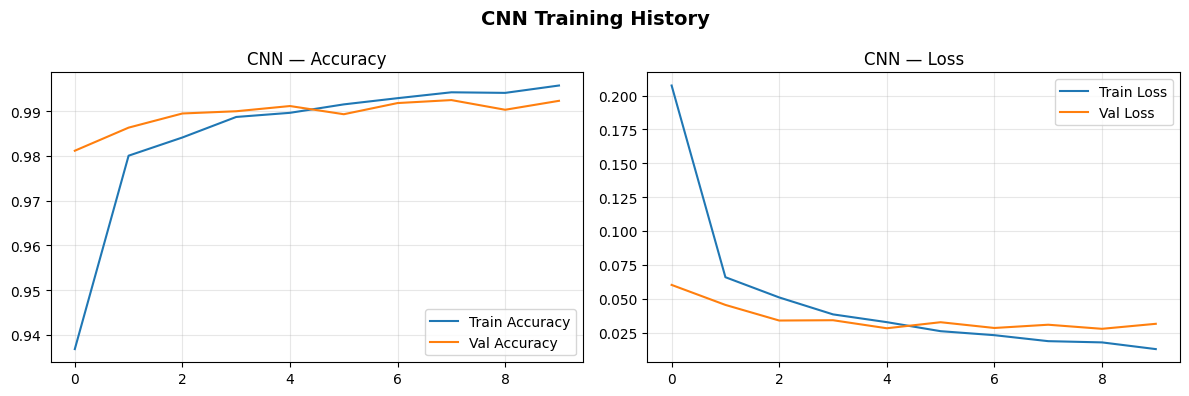

In [43]:
if TF_AVAILABLE:
    # Reshape for CNN: (samples, 28, 28, 1)
    x_train_cnn = x_train.reshape(-1, 28, 28, 1)
    x_test_cnn  = x_test.reshape(-1, 28, 28, 1)
    y_train_cat  = to_categorical(y_train, 10)
    y_test_cat   = to_categorical(y_test,  10)

    # Build CNN
    cnn_model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(10,  activation='softmax')
    ])

    cnn_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    cnn_model.summary()

    # Train CNN
    history = cnn_model.fit(
        x_train_cnn, y_train_cat,
        epochs=10,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    # Evaluate CNN
    loss, acc_cnn = cnn_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
    print(f'\n CNN Test Accuracy: {acc_cnn*100:.2f}%')

    # Plot CNN accuracy
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title('CNN — Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title('CNN — Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('CNN Training History', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('⚠️ Skipping CNN — TensorFlow not installed.')
    print('   MLP Neural Network above is your main model.')

In [ ]:
print('=' * 55)
print('   HANDWRITTEN CHARACTER RECOGNITION — RESULTS')
print('=' * 55)
print(f'   Dataset          : MNIST (70,000 samples, 28×28)')
print(f'   Classes          : 10 (digits 0-9)')
print(f'   Train / Test     : 60,000 / 10,000')
print('-' * 55)
print(f'   Binary CLF (LR)  : ~90% (digit 2 vs rest)')
print(f'   Logistic Reg     : {accuracy_score(y_test, y_pred_multi)*100:.2f}%')
print(f'   MLP Neural Net   : {accuracy_score(y_test, y_pred_mlp)*100:.2f}%')
if TF_AVAILABLE:
    print(f'   CNN (TensorFlow) : {acc_cnn*100:.2f}%')


   HANDWRITTEN CHARACTER RECOGNITION — RESULTS
   Dataset          : MNIST (70,000 samples, 28×28)
   Classes          : 10 (digits 0-9)
   Train / Test     : 60,000 / 10,000
-------------------------------------------------------
   Binary CLF (LR)  : ~90% (digit 2 vs rest)
   Logistic Reg     : 92.49%
   MLP Neural Net   : 98.06%
   CNN (TensorFlow) : 99.04%
